# Nudity Detection — Model Comparison

Compares four nudity/NSFW detection models on two test images:
- **img1.jpg** — contains nudity  
- **img2.webp** — safe / no nudity

Models evaluated:
| Model | Architecture | Labels |
|---|---|---|
| `nudenet` | YOLOv8-nano ONNX object detector | per-body-part bounding boxes |
| `nudedetector` | ViT-Base image classifier | explicit / suggestive / normal |
| `laion_nsfw` | ViT-Base image classifier | nsfw / normal |
| `open_nsfw` | ResNet-50 (Yahoo) binary classifier | NSFW / SFW |

## 0. Setup

In [1]:
from pathlib import Path
import sys, os

# ╔══════════════════════════════════════════════════════════════════════╗
# ║  CONFIGURATION  — the only line you normally need to change        ║
# ╚══════════════════════════════════════════════════════════════════════╝

# Path to your images folder (relative to VLM_checker/, or absolute).
# Default: the 'imgs' folder that lives next to VLM_checker/.
IMG_DIR_CFG = Path('../imgs')
# IMG_DIR_CFG = Path('/absolute/path/to/your/images')  # ← absolute override

# ── Auto-detect VLM_checker root ──────────────────────────────────────────
# Works whether Jupyter is launched from VLM_checker/ or notebooks/.
_cwd = Path().resolve()
if   (_cwd        / 'cli.py').exists():  REPO_ROOT = _cwd
elif (_cwd.parent / 'cli.py').exists():  REPO_ROOT = _cwd.parent
else:                                    REPO_ROOT = _cwd

# Resolve image dir relative to REPO_ROOT  (../imgs → sibling of VLM_checker)
IMG_DIR = (REPO_ROOT / IMG_DIR_CFG).resolve()

# Add VLM_checker to Python path so `from detectors import …` works
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Colab: install dependencies ───────────────────────────────────────────
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    os.system('pip install -q nudenet transformers huggingface_hub opennsfw2 keras onnxruntime Pillow tqdm')

assert IMG_DIR.exists(), (
    f'IMG_DIR not found: {IMG_DIR}\n'
    f'Edit IMG_DIR_CFG in this cell to point at your images folder.'
)
print(f'REPO_ROOT : {REPO_ROOT}')
print(f'IMG_DIR   : {IMG_DIR}')
print(f'Images    : {[f.name for f in sorted(IMG_DIR.iterdir()) if not f.name.startswith(".")]}')


In [2]:
import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.WARNING)

import json
import time
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Test image paths  (IMG_DIR is a pathlib.Path set in the cell above)
IMG1 = str(IMG_DIR / 'img1.jpg')   # nude
IMG2 = str(IMG_DIR / 'img2.webp')  # safe
IMAGES = {'img1 (nude)': IMG1, 'img2 (safe)': IMG2}
MODELS = ['nudenet', 'nudedetector', 'laion_nsfw', 'open_nsfw']

print('Images found:', all(os.path.exists(p) for p in [IMG1, IMG2]))

## 1. Preview Test Images

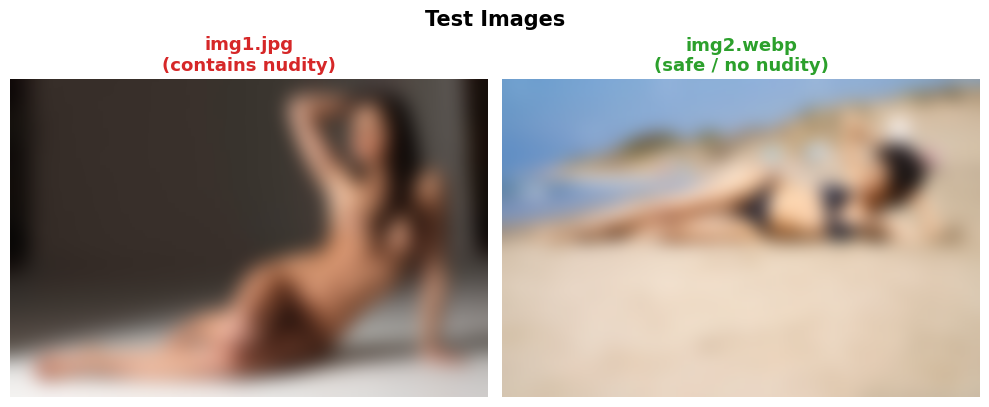

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
labels = ['img1.jpg\n(contains nudity)', 'img2.webp\n(safe / no nudity)']
colors = ['#d62728', '#2ca02c']

for ax, (path, label, color) in zip(axes, [(IMG1, labels[0], colors[0]),
                                             (IMG2, labels[1], colors[1])]):
    img = Image.open(path).convert('RGB')
    # Blur nudity for display
    if 'nudity' in label:
        from PIL import ImageFilter
        img = img.filter(ImageFilter.GaussianBlur(radius=20))
    ax.imshow(img)
    ax.set_title(label, fontsize=13, color=color, fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.suptitle('Test Images', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('test_images_preview.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Run All Models

In [4]:
import os
os.chdir('/Users/trimbachkatya/Documents/Claude/Projects/VLM checker/VLM_checker')

from detectors import create_detector

THRESHOLD = 0.7
results   = {}   # results[model][image_label] = DetectionResult
timings   = {}   # timings[model] = seconds

for model_name in MODELS:
    print(f'\n{'─'*55}')
    print(f'  Model: {model_name}')
    print(f'{'─'*55}')
    try:
        detector = create_detector(model_name, threshold=THRESHOLD)
        results[model_name] = {}
        t0 = time.perf_counter()

        for img_label, img_path in IMAGES.items():
            r = detector.predict(img_path)
            results[model_name][img_label] = r
            verdict = '✅ NUDE' if r.contains_nudity else '✅ SAFE'
            print(f'  {img_label:20s}  confidence={r.confidence:.3f}  {verdict}')
            if r.categories:
                top = r.categories[0]
                print(f'  {'':20s}  top category: {top.label} ({top.score:.3f})')

        timings[model_name] = time.perf_counter() - t0
        print(f'  Total time: {timings[model_name]:.1f}s')

    except Exception as e:
        print(f'  ERROR: {e}')
        results[model_name] = None
        timings[model_name] = 0

print('\nDone.')

## 3. Summarise Raw Scores

In [5]:
print(f"{'Model':<18} {'img1 (nude) conf':>18} {'img2 (safe) conf':>18} {'img1 correct':>14} {'img2 correct':>14}")
print('─' * 86)

for m in MODELS:
    if results[m] is None:
        print(f"{m:<18} {'ERROR':>18} {'ERROR':>18}")
        continue
    r1 = results[m].get('img1 (nude)')
    r2 = results[m].get('img2 (safe)')
    c1 = f"{r1.confidence:.3f}" if r1 else 'N/A'
    c2 = f"{r2.confidence:.3f}" if r2 else 'N/A'
    ok1 = '✅' if (r1 and r1.contains_nudity) else '❌'
    ok2 = '✅' if (r2 and not r2.contains_nudity) else '❌'
    print(f"{m:<18} {c1:>18} {c2:>18} {ok1:>14} {ok2:>14}")

Model                img1 (nude) conf   img2 (safe) conf   img1 correct   img2 correct
──────────────────────────────────────────────────────────────────────────────────────
nudenet                         0.827              0.000              ✅              ✅
nudedetector                    0.999              0.930              ✅              ❌
laion_nsfw                      1.000              0.000              ✅              ✅
open_nsfw                       0.998              0.062              ✅              ✅


## 4. Confidence Score Comparison (Bar Chart)

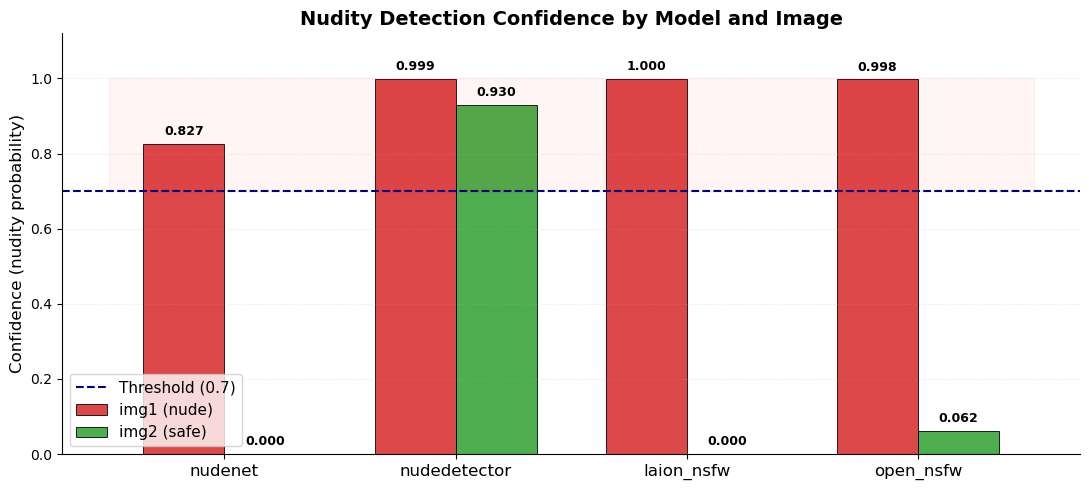

In [6]:
valid_models = [m for m in MODELS if results.get(m)]
x = np.arange(len(valid_models))
width = 0.35

scores_nude = [results[m]['img1 (nude)'].confidence for m in valid_models]
scores_safe = [results[m]['img2 (safe)'].confidence for m in valid_models]

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2, scores_nude, width, label='img1 (nude)',
               color='#d62728', alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = ax.bar(x + width/2, scores_safe, width, label='img2 (safe)',
               color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7)

# Threshold line
ax.axhline(THRESHOLD, color='navy', linewidth=1.5, linestyle='--',
           label=f'Threshold ({THRESHOLD})')
ax.fill_between([-0.5, len(valid_models) - 0.5], THRESHOLD, 1.0,
                color='red', alpha=0.04)

# Value labels
for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(valid_models, fontsize=12)
ax.set_ylabel('Confidence (nudity probability)', fontsize=12)
ax.set_title('Nudity Detection Confidence by Model and Image', fontsize=14, fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle=':')

plt.tight_layout()
plt.savefig('confidence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correct / Incorrect Classification Heatmap

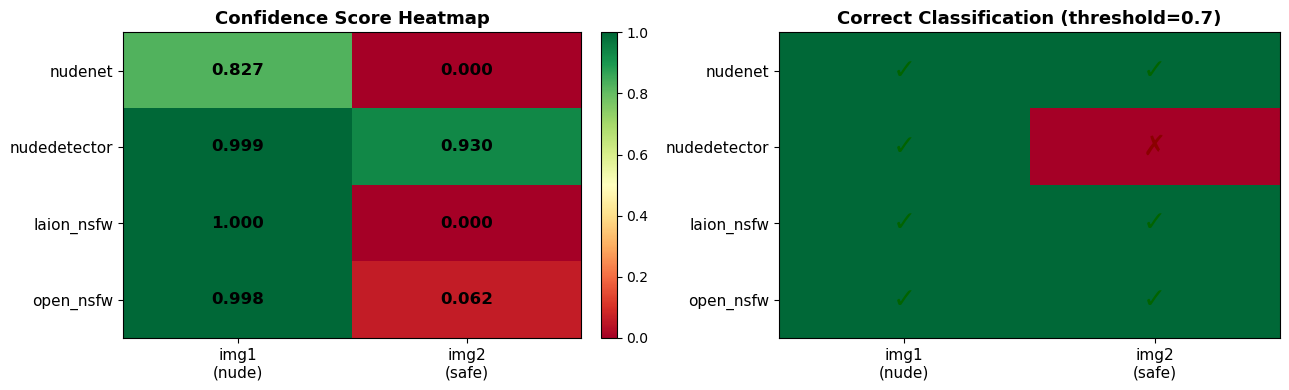

In [7]:
img_labels = ['img1 (nude)', 'img2 (safe)']
ground_truth_nudity = [True, False]   # expected contains_nudity

matrix = np.zeros((len(valid_models), 2))   # 1=correct, 0=wrong
conf_matrix = np.zeros((len(valid_models), 2))

for i, m in enumerate(valid_models):
    for j, (lbl, expected) in enumerate(zip(img_labels, ground_truth_nudity)):
        r = results[m][lbl]
        conf_matrix[i, j] = r.confidence
        matrix[i, j] = 1.0 if (r.contains_nudity == expected) else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# ── Heatmap: Confidence ────────────────────────────────────────────────────
im1 = ax1.imshow(conf_matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['img1\n(nude)', 'img2\n(safe)'], fontsize=11)
ax1.set_yticks(range(len(valid_models)))
ax1.set_yticklabels(valid_models, fontsize=11)
ax1.set_title('Confidence Score Heatmap', fontsize=13, fontweight='bold')
for i in range(len(valid_models)):
    for j in range(2):
        ax1.text(j, i, f'{conf_matrix[i,j]:.3f}',
                 ha='center', va='center', fontsize=12, fontweight='bold',
                 color='black')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# ── Heatmap: Correct / Wrong ───────────────────────────────────────────────
im2 = ax2.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_xticklabels(['img1\n(nude)', 'img2\n(safe)'], fontsize=11)
ax2.set_yticks(range(len(valid_models)))
ax2.set_yticklabels(valid_models, fontsize=11)
ax2.set_title(f'Correct Classification (threshold={THRESHOLD})', fontsize=13, fontweight='bold')
for i in range(len(valid_models)):
    for j in range(2):
        symbol = '✓' if matrix[i, j] else '✗'
        ax2.text(j, i, symbol, ha='center', va='center', fontsize=20,
                 color='darkgreen' if matrix[i, j] else 'darkred', fontweight='bold')

plt.tight_layout()
plt.savefig('classification_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Detected Categories per Model

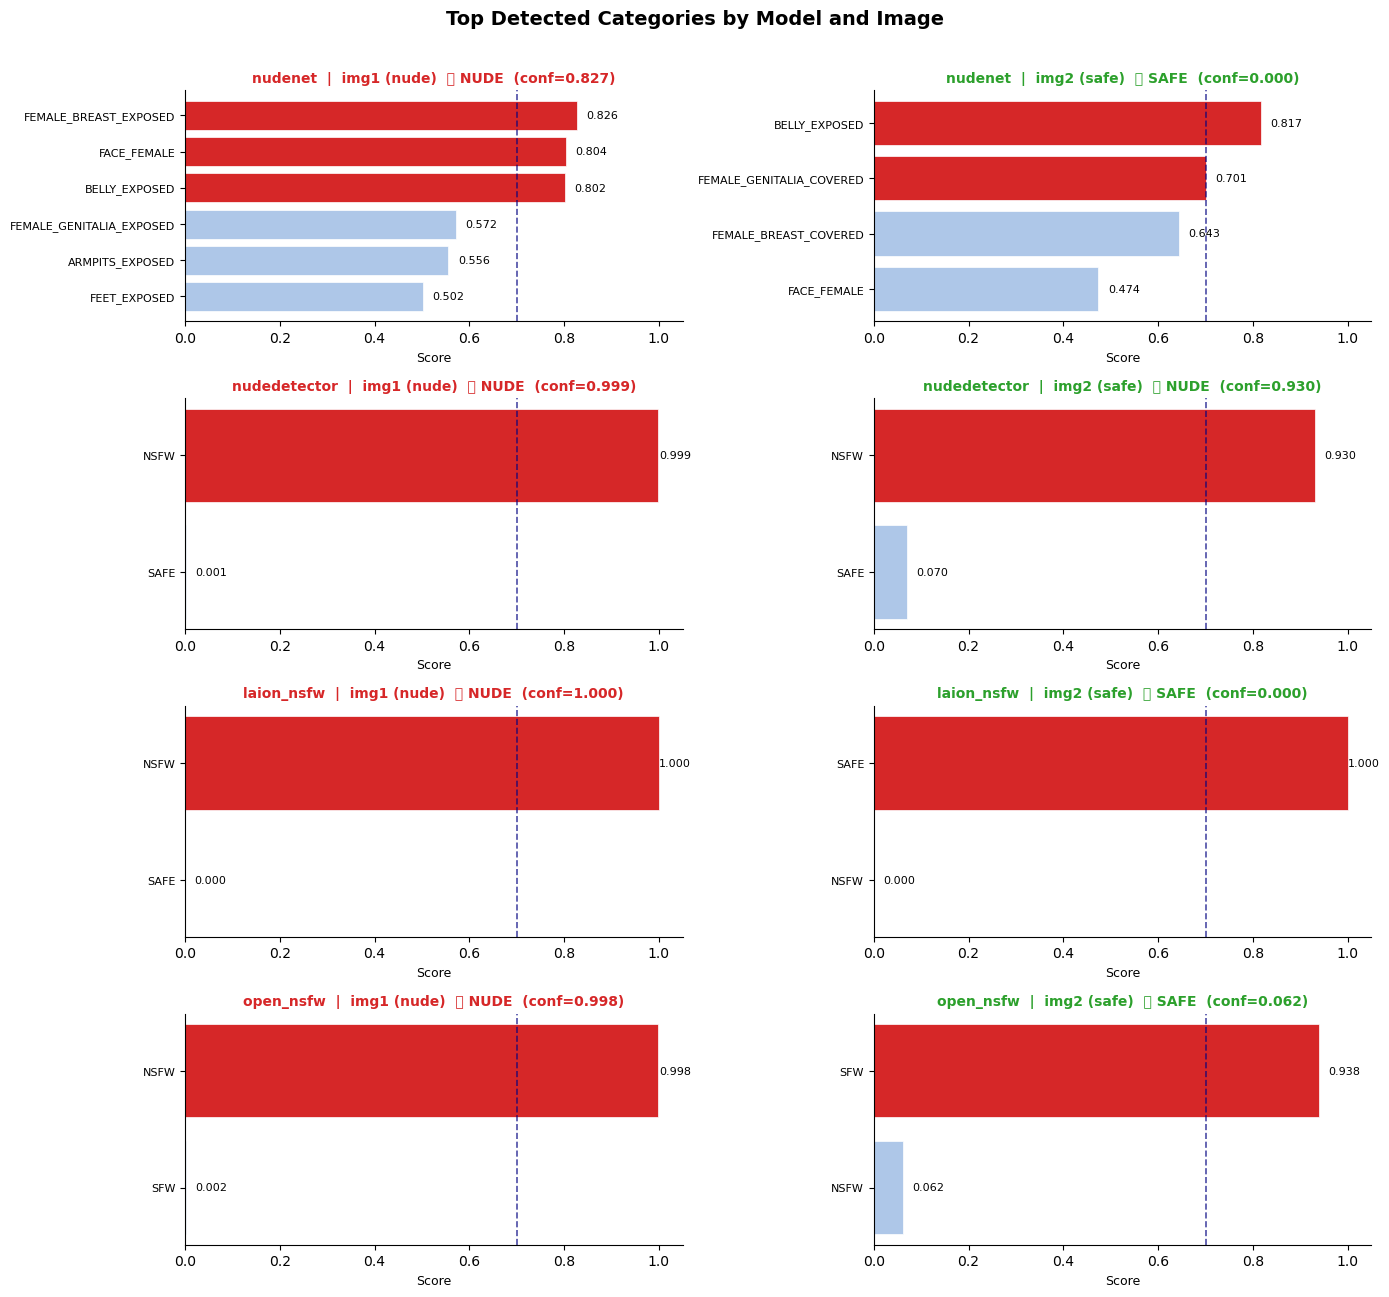

In [8]:
fig, axes = plt.subplots(len(valid_models), 2,
                          figsize=(14, 3.2 * len(valid_models)),
                          sharey=False)
if len(valid_models) == 1:
    axes = [axes]

img_col_colors = ['#d62728', '#2ca02c']
img_col_titles = ['img1 (nude)', 'img2 (safe)']

for row, m in enumerate(valid_models):
    for col, (lbl, color) in enumerate(zip(img_col_titles, img_col_colors)):
        ax = axes[row][col]
        r = results[m][lbl]
        cats = r.categories[:6]   # top 6
        if not cats:
            ax.text(0.5, 0.5, 'No detections', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11, color='grey')
            ax.set_title(f'{m} | {lbl}', fontsize=10)
            ax.axis('off')
            continue

        labels_list = [c.label for c in cats]
        scores_list = [c.score for c in cats]
        bar_colors  = ['#d62728' if s >= THRESHOLD else '#aec7e8' for s in scores_list]

        bars = ax.barh(labels_list[::-1], scores_list[::-1],
                       color=bar_colors[::-1], edgecolor='white', linewidth=0.5)
        ax.axvline(THRESHOLD, color='navy', linewidth=1.2, linestyle='--', alpha=0.7)
        ax.set_xlim(0, 1.05)
        ax.set_xlabel('Score', fontsize=9)
        verdict = '🔴 NUDE' if r.contains_nudity else '🟢 SAFE'
        ax.set_title(f'{m}  |  {lbl}  {verdict}  (conf={r.confidence:.3f})',
                     fontsize=10, color=color, fontweight='bold')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.tick_params(axis='y', labelsize=8)
        for bar, score in zip(bars, scores_list[::-1]):
            ax.text(min(score + 0.02, 1.0), bar.get_y() + bar.get_height()/2,
                    f'{score:.3f}', va='center', fontsize=8)

plt.suptitle('Top Detected Categories by Model and Image', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('category_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Inference Time Comparison

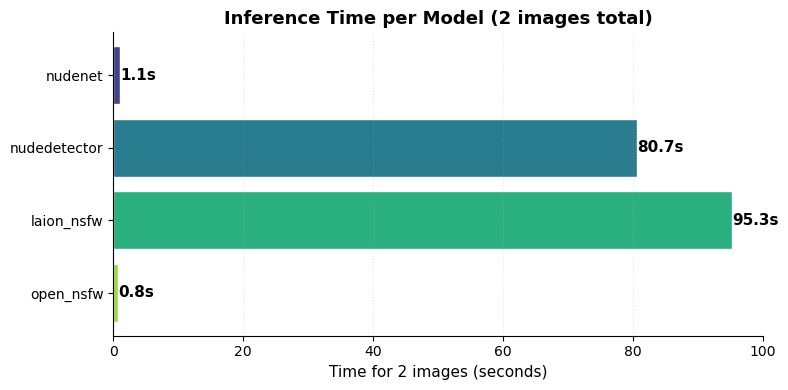

Note: first run includes model weight loading/downloading.


In [9]:
valid_times = [(m, timings[m]) for m in valid_models]
mnames, mtimes = zip(*valid_times)

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(mnames)))
bars = ax.barh(mnames, mtimes, color=bar_colors, edgecolor='white')

for bar, t in zip(bars, mtimes):
    ax.text(t + 0.05, bar.get_y() + bar.get_height()/2,
            f'{t:.1f}s', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Time for 2 images (seconds)', fontsize=11)
ax.set_title('Inference Time per Model (2 images total)', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('inference_time.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: first run includes model weight loading/downloading.')

## 8. Score Radar Chart — img1 (nude)

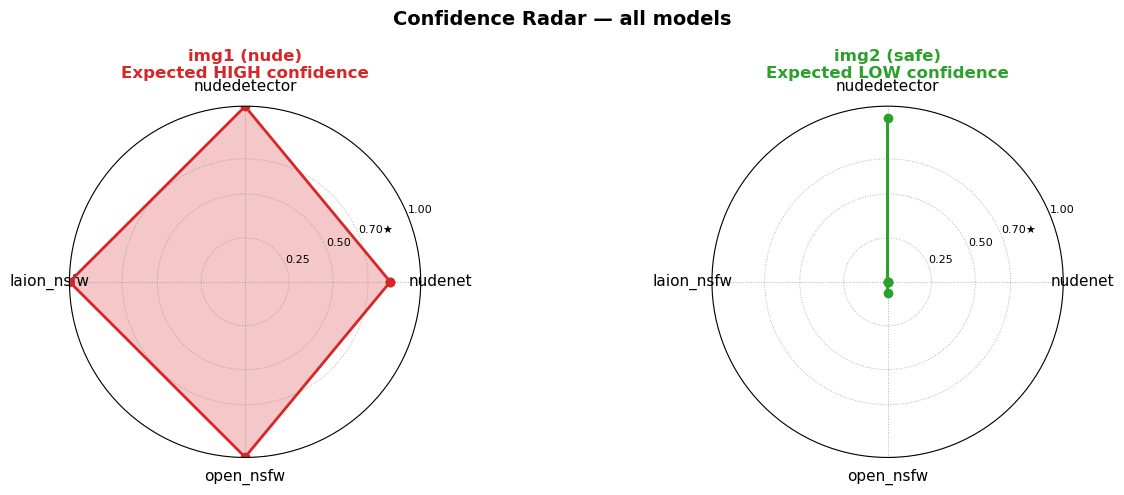

In [10]:
angles = np.linspace(0, 2 * np.pi, len(valid_models), endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(1, 2, figsize=(13, 5), subplot_kw=dict(polar=True))
plot_configs = [
    ('img1 (nude)', '#d62728', 'Expected HIGH confidence'),
    ('img2 (safe)', '#2ca02c', 'Expected LOW confidence'),
]

for ax, (lbl, color, subtitle) in zip(axes, plot_configs):
    vals = [results[m][lbl].confidence for m in valid_models]
    vals += vals[:1]

    ax.plot(angles, vals, 'o-', linewidth=2, color=color)
    ax.fill(angles, vals, alpha=0.25, color=color)
    ax.set_thetagrids(np.degrees(angles[:-1]), valid_models, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.7, 1.0])
    ax.set_yticklabels(['0.25', '0.50', '0.70★', '1.00'], fontsize=8)
    ax.set_title(f'{lbl}\n{subtitle}', fontsize=12, fontweight='bold',
                 color=color, pad=20)
    ax.grid(color='grey', linestyle=':', linewidth=0.7, alpha=0.6)

plt.suptitle('Confidence Radar — all models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Full JSON Output

In [11]:
summary = {}
for m in valid_models:
    summary[m] = {}
    for lbl in img_labels:
        r = results[m][lbl]
        summary[m][lbl] = r.to_dict()

print(json.dumps(summary, indent=2))

{
  "nudenet": {
    "img1 (nude)": {
      "contains_nudity": true,
      "confidence": 0.8265,
      "model": "nudenet",
      "categories": [
        {
          "label": "FEMALE_BREAST_EXPOSED",
          "score": 0.8265
        },
        {
          "label": "FACE_FEMALE",
          "score": 0.8036
        },
        {
          "label": "BELLY_EXPOSED",
          "score": 0.8017
        },
        {
          "label": "FEMALE_GENITALIA_EXPOSED",
          "score": 0.5724
        },
        {
          "label": "ARMPITS_EXPOSED",
          "score": 0.5559
        },
        {
          "label": "FEET_EXPOSED",
          "score": 0.5019
        }
      ]
    },
    "img2 (safe)": {
      "contains_nudity": false,
      "confidence": 0.0,
      "model": "nudenet",
      "categories": [
        {
          "label": "BELLY_EXPOSED",
          "score": 0.8165
        },
        {
          "label": "FEMALE_GENITALIA_COVERED",
          "score": 0.701
        },
        {
          "la

## 10. Findings Summary

In [12]:
print('=' * 60)
print('FINDINGS SUMMARY')
print('=' * 60)

all_correct = []
for m in valid_models:
    r1 = results[m]['img1 (nude)']
    r2 = results[m]['img2 (safe)']
    correct_nude = r1.contains_nudity
    correct_safe = not r2.contains_nudity
    both = correct_nude and correct_safe
    all_correct.append(both)
    delta = r1.confidence - r2.confidence  # separation between nude and safe
    print(f'\n{m}')
    print(f'  img1 (nude) confidence : {r1.confidence:.3f}  → {"✅ CORRECT" if correct_nude else "❌ WRONG"}')
    print(f'  img2 (safe) confidence : {r2.confidence:.3f}  → {"✅ CORRECT" if correct_safe else "❌ WRONG"}')
    print(f'  Score separation       : {delta:+.3f}  (higher = better discrimination)')
    print(f'  Both correct?          : {"✅ YES" if both else "❌ NO"}')

print('\n' + '=' * 60)
n_correct = sum(all_correct)
print(f'Overall: {n_correct}/{len(valid_models)} models classified both images correctly')
print('=' * 60)

FINDINGS SUMMARY

nudenet
  img1 (nude) confidence : 0.827  → ✅ CORRECT
  img2 (safe) confidence : 0.000  → ✅ CORRECT
  Score separation       : +0.827  (higher = better discrimination)
  Both correct?          : ✅ YES

nudedetector
  img1 (nude) confidence : 0.999  → ✅ CORRECT
  img2 (safe) confidence : 0.930  → ❌ WRONG
  Score separation       : +0.069  (higher = better discrimination)
  Both correct?          : ❌ NO

laion_nsfw
  img1 (nude) confidence : 1.000  → ✅ CORRECT
  img2 (safe) confidence : 0.000  → ✅ CORRECT
  Score separation       : +0.999  (higher = better discrimination)
  Both correct?          : ✅ YES

open_nsfw
  img1 (nude) confidence : 0.998  → ✅ CORRECT
  img2 (safe) confidence : 0.062  → ✅ CORRECT
  Score separation       : +0.936  (higher = better discrimination)
  Both correct?          : ✅ YES

Overall: 3/4 models classified both images correctly
